```text
Capital analysis
├── Import & Setup
├── PD and LGD estimation
└── Capital estimation
    ├── Capital concentration
    ├── Loss distribution
    └── Capital reduction
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe, apply_pipe_LGD, estimate_capital
from src.plots import my_heatmap, plot_loss_distribution
from src.preprocessing import my_input_load, ReplaceMinusOne
from src.validation import validate_predictions

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = my_input_load(2019, 2020)
portfolio, dr_summary = create_target_def12(portfolio)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


## PD and LGD estimation

In [4]:
# import pipelines

import joblib
pipeline_pd  = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_lgd = joblib.load("../models/PIPELINE_LGD_Amount.pkl")

In [5]:
# apply pipelines

portfolio = apply_pipe(portfolio, pipeline_pd)
portfolio = apply_pipe_LGD(portfolio, pipeline_lgd)

In [6]:
# validate model output

validate_predictions(portfolio)

----------------------------------------
MODEL OUTPUT VALIDATION
----------------------------------------


,PD,LGD
Min,0.000,0.000
Mean,0.150,0.132
Max,0.595,0.224
NaNs,0.000,0.000


## Capital estimation

Methods:

1. simple proxy: Capital = 2 * Expected Loss
1. Monte-Carlo method                        
1. stress proxy: Capital = 5 * Expected Loss

As a validation step, a simple capital proxy defined as 2×Expected Loss is evaluated on the 2019–2020 portfolio. Since the proxy is a constant multiple of Expected Loss, the resulting capital contribution heatmap is expected to match the Expected Loss heatmap exactly. This confirms the correctness of the capital calculation and visualization pipeline before introducing the Monte Carlo estimator.

#### Capital concentration

selected variable:  CAP
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.029282  0.043009  0.058625  0.085654  0.145875
50–70%   0.035146  0.072426  0.105585  0.144007  0.259950
70–100%  0.000582  0.001784  0.004046  0.006260  0.007769


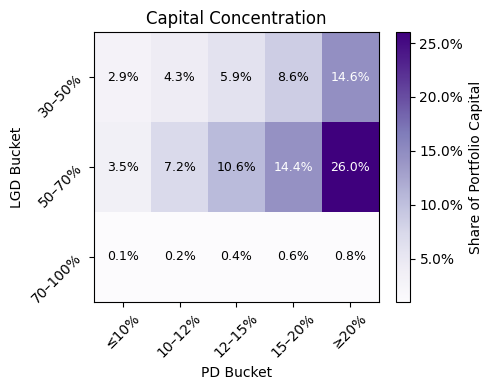

In [7]:
# capital estimation 'simple proxy' with observed LGDs

capital_with_realLGD = estimate_capital(portfolio, method="simple", column_lgd="LossGivenDefault")
my_heatmap(capital_with_realLGD, variable="CAP", column_lgd="LossGivenDefault")

selected variable:  CAP
            ≤10%    10–12%    12–15%    15–20%      ≥20%
0–10%   0.003258  0.006612  0.012253  0.019050  0.037105
10–30%  0.066171  0.109781  0.149990  0.207833  0.387946


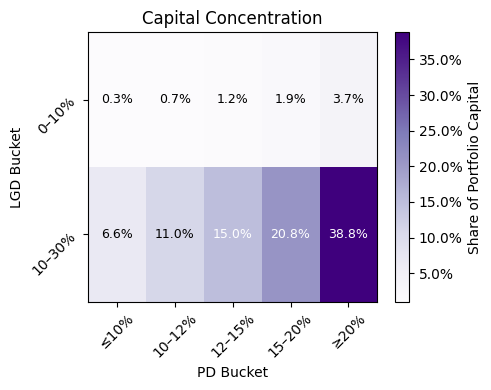

In [8]:
# capital estimation 'simple proxy' with predicted LGDs

capital_with_predLGD = estimate_capital(portfolio, method="simple", column_lgd="LGD")
my_heatmap(capital_with_predLGD, variable="CAP", column_lgd="LGD")

#### Loss distribution

----------------------------------------
Monte Carlo validation
----------------------------------------
DR (mean) observed  :       0.1481
PD (mean) predicted :       0.1500
Simulated DR (mean) :       0.1500
Simulated DR (std)  :       0.0016
Nr simulations      :        10000
----------------------------------------
----------------------------------------
Portfolio Loss summary
----------------------------------------
EAD                 :  116,382,285
Loss (min)          :    2,547,918
Loss (mean)         :    2,690,483
Loss (std)          :       38,289
Loss (max)          :    2,833,322
VaR 95%             :    2,753,861
VaR 99%             :    2,779,117
VaR 99.9%           :    2,815,870
Economic Capital    :      125,388
----------------------------------------
----------------------------------------
Expected Loss comparison
----------------------------------------
EL (deterministic)  :    2,689,982
EL (MC-simulated)   :    2,690,483
Difference          :         -501
Differ

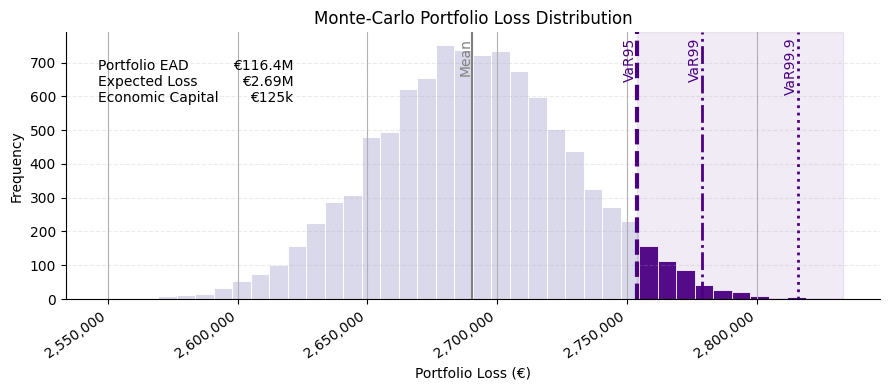

In [9]:
# capital estimation 'monte-carlo' with predicted LGDs

capital_with_predLGD = estimate_capital(portfolio, method="monte-carlo", column_lgd="LGD")